# Decision tree met Gini 

Je kunt een library gebruiken om Decision tree te trainen. Hieronder geven we een voorbeeld voor de MNIST database.

Let er op dat de enige features die hier worden gebruikt pixelwaardes op locaties zijn. Dus:

- enkel rauwe pixel intensiteiten
- 1 pixel = 1 numerical feature
- Er is geen feature die gaat over ruimtelijk begrip, filtering, of anderen (eg symmetrie in verticale as, aantal gaten etc)

Importeer de libaries, laad de mnist db en spilt test en training set.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report


mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist['data']
y = mnist['target'] 
y = y.astype(int)       

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Trainen van een decision tree is nu heel simpel. We gebruiken ***max_depth = 20*** om er voor te zorgen dat de decision tree niet overtraint. 

Wat is overtrainen hier en waarom denk je dat het nodig is?

Overtrainen betekent dat de boom zo diep groeit dat hij de trainingsdata uit zijn hoofd leert in plaats van algemene patronen. Zonder max_depth groeit de boom totdat elk blad één trainingsplaatje bevat: 100% nauwkeurig op train, maar slecht op nieuwe plaatjes. max_depth=20 voorkomt dat.

In [2]:
dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=20,    
    random_state=42
)

dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

Doe nu de voorspellingen en laat de precisie zien.

In [3]:
y_pred = dt.predict(X_test)


acc = accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy on MNIST:", acc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Decision Tree Accuracy on MNIST: 0.8719285714285714

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      1343
           1       0.94      0.96      0.95      1600
           2       0.86      0.83      0.85      1380
           3       0.85      0.84      0.84      1433
           4       0.84      0.87      0.86      1295
           5       0.83      0.82      0.83      1273
           6       0.90      0.91      0.90      1396
           7       0.91      0.91      0.91      1503
           8       0.81      0.79      0.80      1357
           9       0.84      0.84      0.84      1420

    accuracy                           0.87     14000
   macro avg       0.87      0.87      0.87     14000
weighted avg       0.87      0.87      0.87     14000



- Zoek uit waar de waardes in de classification report voor staan of je eigen eerder gemaakte keuzes toe te lichten.

- Is de waarde hoger dan wat jij in je eerdere Decision tree had? Waarom denk je?

**precision**: van alle keren dat het model dit cijfer voorspelde, hoe vaak klopte dat.  
**recall**: van alle echte plaatjes van dit cijfer, hoeveel werden correct herkend.  
**f1-score**: combinatie van precision en recall.  
**support**: aantal testplaatjes voor dat cijfer.

Ja, de accuracy is veel hoger dan de ~39,6% van de P3 boom. Sklearn gebruikt alle 784 pixels als features in plaats van 11 handgemaakte features, heeft meer trainingsdata (56.000 vs 5.000) en vindt betere splitsingen.

Je kunt de boom ook met een library laten zien. Let er op dat je een limiet instelt op hoeveel lagen je toont (gebruik **max_depth=klein_getal**)

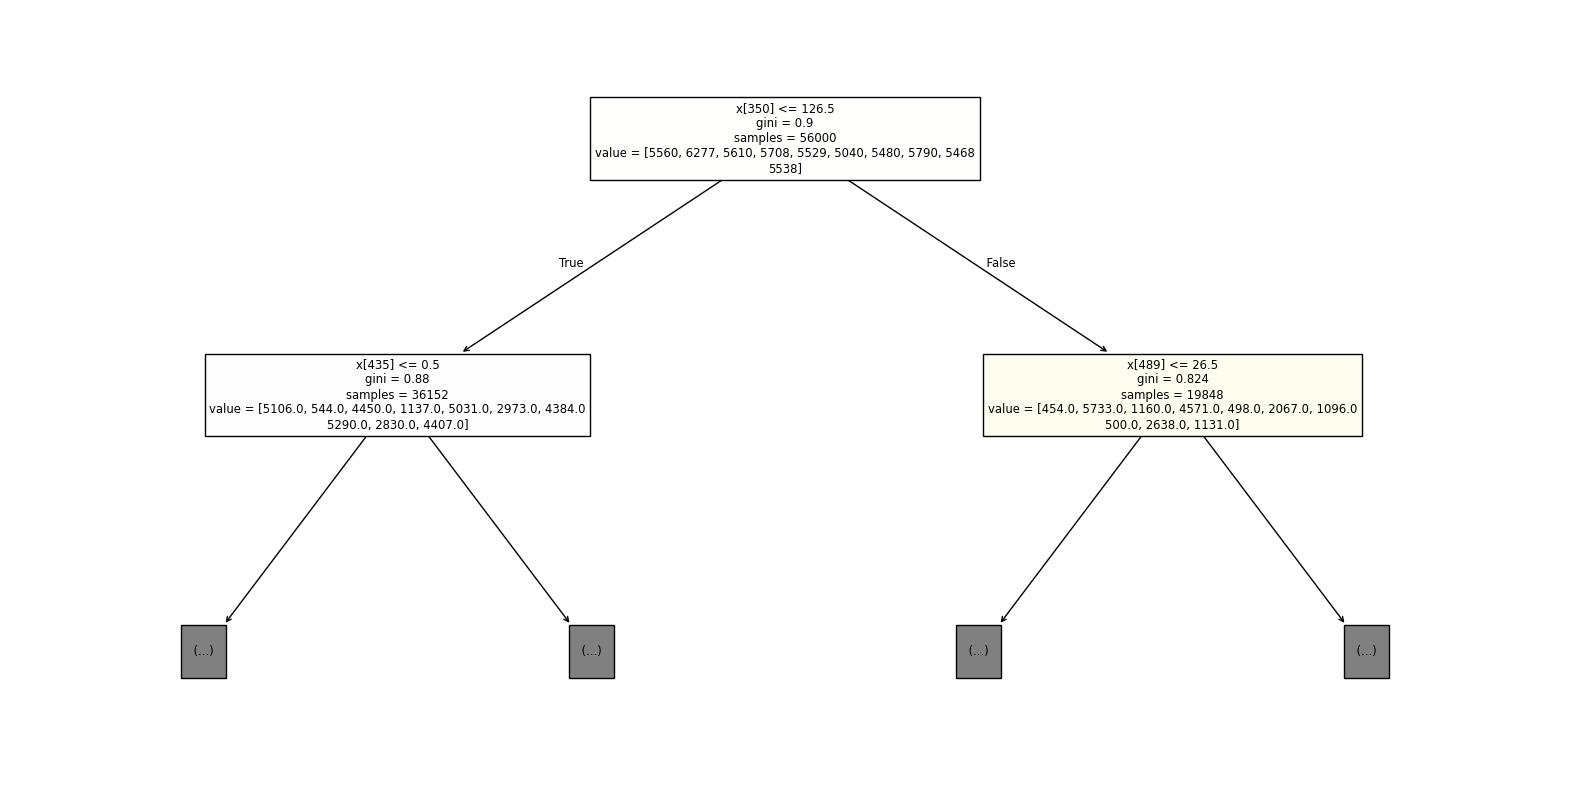

In [4]:
from sklearn import tree
plt.figure(figsize=(20,10))
tree.plot_tree(dt, max_depth=1, filled=True)
plt.show()

Laten we nu kijken of je betere resultaten kunt krijgen uit de features die je zelf eerder hebt bedacht.

In [5]:
DREMPEL = 128

def procent_donkere_pixels(img):
    return np.sum(img > DREMPEL) / img.size

def links_vs_rechts(img):
    links  = np.mean(img[:, :14].astype(float))
    rechts = np.mean(img[:, 14:].astype(float))
    return links - rechts

def boven_vs_onder(img):
    boven = np.mean(img[:14].astype(float))
    onder = np.mean(img[14:].astype(float))
    return boven - onder

def symmetrie_horizontaal(img):
    spiegel = img[:, ::-1]
    return np.mean(np.abs(img.astype(float) - spiegel.astype(float)))

def symmetrie_verticaal(img):
    spiegel = img[::-1]
    return np.mean(np.abs(img.astype(float) - spiegel.astype(float)))

def standaardafwijking(img):
    return np.std(img.astype(float))

def zwaartepunt_rij(img):
    rijen = np.arange(28).reshape(28, 1)
    return np.sum(rijen * img) / (np.sum(img) + 1e-6)

def pixels_rechtsonder(img):
    return np.sum(img[14:, 14:] > DREMPEL) / (14 * 14)

def pixels_rechtsboven(img):
    return np.sum(img[:14, 14:] > DREMPEL) / (14 * 14)

def pixels_linksonder(img):
    return np.sum(img[14:, :14] > DREMPEL) / (14 * 14)

def pixels_linksboven(img):
    return np.sum(img[:14, :14] > DREMPEL) / (14 * 14)

def extract_features(img):
    return [
        procent_donkere_pixels(img),
        links_vs_rechts(img),
        boven_vs_onder(img),
        symmetrie_horizontaal(img),
        symmetrie_verticaal(img),
        standaardafwijking(img),
        zwaartepunt_rij(img),
        pixels_rechtsonder(img),
        pixels_rechtsboven(img),
        pixels_linksonder(img),
        pixels_linksboven(img),
    ]


def extract_features_batch(X_flat):
    imgs = X_flat.reshape(-1, 28, 28)
    feature_list = []

    for img in imgs:
        feats = extract_features(img)   # Deze hebben jullie eerder gemaakt! Gebruik hier je oude extract_features functie
        feature_list.append(feats)

    return np.array(feature_list)       # shape: (n_samples, n_student_features)

X_student = extract_features_batch(X)

# combineer de standaard features met jouw nieuwe features
# Dit is dus wat we hadden: (70000, 784)
# stel je hebt zelf 11 features aangemaakt
# Dan is dit wat het wordt: (70000, 784 + 11)
X_combined = np.hstack([X, X_student])
print("Combined shape:", X_combined.shape)

X_combined_train, X_combined_test, _, _ = train_test_split(X_combined, y, test_size=0.2, random_state=42)

dt_combined = DecisionTreeClassifier(criterion='gini', max_depth=20, random_state=42)
dt_combined.fit(X_combined_train, y_train)
y_pred_combined = dt_combined.predict(X_combined_test)
acc_combined = accuracy_score(y_test, y_pred_combined)
print("Accuracy gecombineerde features:", acc_combined)
print("Accuracy alleen pixels:", acc)

Combined shape: (70000, 795)
Accuracy gecombineerde features: 0.8762142857142857
Accuracy alleen pixels: 0.8719285714285714


- Heb je nu betere resultaten?

Nauwelijks. De 784 pixels bevatten al bijna alle informatie; de 11 eigen features zijn patronen die de boom al uit de pixelwaarden zelf kan afleiden.

En wat nou als je alleen je oude features gebruikt? 

In [6]:
X_student_train, X_student_test, _, _ = train_test_split(X_student, y, test_size=0.2, random_state=42)

dt_student = DecisionTreeClassifier(criterion='gini', max_depth=20, random_state=42)
dt_student.fit(X_student_train, y_train)
y_pred_student = dt_student.predict(X_student_test)
acc_student = accuracy_score(y_test, y_pred_student)
print("Accuracy alleen eigen features:", acc_student)
print("Accuracy alleen pixels:", acc)

Accuracy alleen eigen features: 0.49642857142857144
Accuracy alleen pixels: 0.8719285714285714


Met alleen de 11 eigen features is de accuracy lager dan met 784 pixels, maar hoger dan de ~39,6% van de handgebouwde P3 boom. Sklearn vindt betere splitsingen en traint op de volledige dataset van 56.000 plaatjes in plaats van 5.000.